In [2]:
# load libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
# dataset: Career College Key Performance Indicators from the Ontario Data Catalogue
# load dataset
df = pd.read_csv("/Users/emannishat/projects/visualization/02_activities/assignments/assignment_3/overall_2022_kpi_report_for_publication_full_en.csv")

In [4]:
# view dataset
df

# check variables
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3574 entries, 0 to 3573
Data columns (total 16 columns):
 #   Column                                              Non-Null Count  Dtype 
---  ------                                              --------------  ----- 
 0   COLLEGE ID                                          3573 non-null   object
 1   COLLEGE NAME                                        3566 non-null   object
 2   CAMPUS ID                                           3566 non-null   object
 3   CAMPUS                                              3566 non-null   object
 4   CITY/TOWN                                           3205 non-null   object
 5   POSTAL CODE                                         3205 non-null   object
 6   PROGRAM NAME                                        3565 non-null   object
 7   PROGRAM TYPE                                        2676 non-null   object
 8   PROGRAM CATEGORY                                    2676 non-null   object
 9   AUDIT   

In [5]:
# only keep rows with non-null data for PROGRAM TYPE
df_notnull = df[df['PROGRAM TYPE'].notnull()]

In [6]:
# check variables again to make sure we only have non null data
df_notnull.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2676 entries, 3 to 3565
Data columns (total 16 columns):
 #   Column                                              Non-Null Count  Dtype 
---  ------                                              --------------  ----- 
 0   COLLEGE ID                                          2676 non-null   object
 1   COLLEGE NAME                                        2676 non-null   object
 2   CAMPUS ID                                           2676 non-null   object
 3   CAMPUS                                              2676 non-null   object
 4   CITY/TOWN                                           2676 non-null   object
 5   POSTAL CODE                                         2676 non-null   object
 6   PROGRAM NAME                                        2676 non-null   object
 7   PROGRAM TYPE                                        2676 non-null   object
 8   PROGRAM CATEGORY                                    2676 non-null   object
 9   AUDIT        

In [7]:
# list column names
print(df_notnull.columns.tolist())

['COLLEGE ID', 'COLLEGE NAME', 'CAMPUS ID', 'CAMPUS', 'CITY/TOWN', 'POSTAL CODE', 'PROGRAM NAME', 'PROGRAM TYPE', 'PROGRAM CATEGORY', 'AUDIT', 'GRADUATION RATE\n(%)', 'GRADUATE EMPLOYMENT RATE\n(%)', 'GRADUATE EMPLOYMENT RATE IN THE FIELD OF STUDY\n(%)', 'GRADUATE SATISFACTION RATE\n(% Satisfied)', 'EMPLOYER SATISFACTION RATE\n(% Satisfied)', 'OSAP DEFAULT RATE\n(%)']


In [8]:
# rename satisfaction rate columns
df_notnull = df_notnull.rename(columns={
    "GRADUATE SATISFACTION RATE\n(% Satisfied)": "Graduate Satisfaction",
    "EMPLOYER SATISFACTION RATE\n(% Satisfied)": "Employer Satisfaction"
})
df_notnull.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2676 entries, 3 to 3565
Data columns (total 16 columns):
 #   Column                                              Non-Null Count  Dtype 
---  ------                                              --------------  ----- 
 0   COLLEGE ID                                          2676 non-null   object
 1   COLLEGE NAME                                        2676 non-null   object
 2   CAMPUS ID                                           2676 non-null   object
 3   CAMPUS                                              2676 non-null   object
 4   CITY/TOWN                                           2676 non-null   object
 5   POSTAL CODE                                         2676 non-null   object
 6   PROGRAM NAME                                        2676 non-null   object
 7   PROGRAM TYPE                                        2676 non-null   object
 8   PROGRAM CATEGORY                                    2676 non-null   object
 9   AUDIT        

In [9]:
# remove % sign from values in satisfaction rate columns and convert to numeric
# convert to string first, then remove '%' and convert to numeric
df_notnull["Graduate Satisfaction"] = pd.to_numeric(
    df_notnull["Graduate Satisfaction"].astype(str).str.replace('%', '', regex=False).str.strip(), errors='coerce'
)

df_notnull["Employer Satisfaction"] = pd.to_numeric(
    df_notnull["Employer Satisfaction"].astype(str).str.replace('%', '', regex=False).str.strip(), errors='coerce'
)


In [10]:
# replace long program type name with a shorter version to improve visual appearance of plot
df_notnull["PROGRAM TYPE"] = df_notnull["PROGRAM TYPE"].replace({
    "Technical Standards and Safety Authority (TSSA) Restricted Tradesperson": "TSSA Restricted Tradesperson"
})

In [11]:
# create heatmap to display satisfaction scores by program type
# to do this, we need to calculate the average graduate and employer satisfaction rate for each program

heatmap_data = df_notnull.groupby("PROGRAM TYPE")[[ # want average rates for each program
    "Graduate Satisfaction", 
    "Employer Satisfaction"
]].mean().round(1) # rounding the average

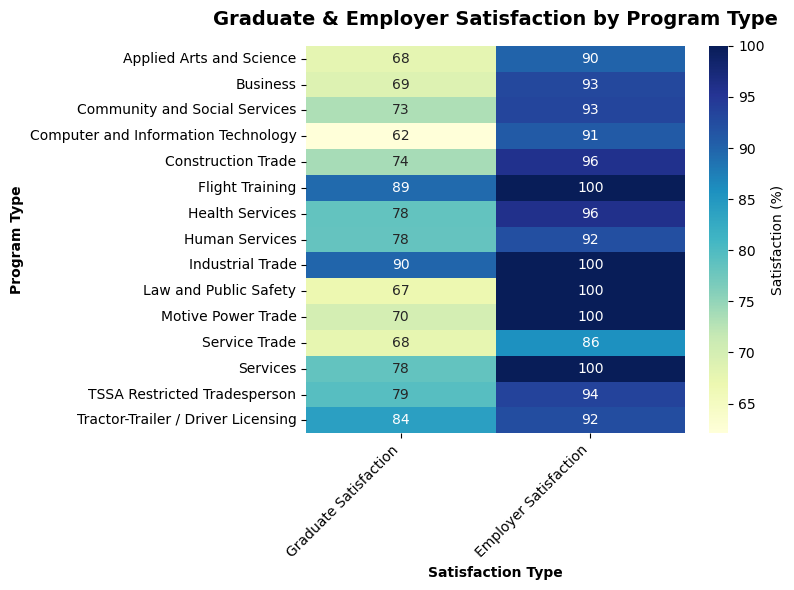

In [16]:
# plot heatmap
plt.figure(figsize=(8, 6))
# want to have annotations that are not in scientific notation (annot=True, fmt=".0f")
# set colour palette as YlGnBu
sns.heatmap(heatmap_data, annot=True, fmt=".0f", cmap="YlGnBu", cbar_kws={"label": "Satisfaction (%)"})
# pad=15 adds space between title and plot to reduce clutter
plt.title("Graduate & Employer Satisfaction by Program Type", fontsize=14, fontweight="bold", pad=15)
plt.ylabel("Program Type", fontweight="bold")
plt.xlabel("Satisfaction Type", fontweight="bold")
# rotate x-axis labels 45 degree so that fit and improve readability
plt.xticks(rotation=45, ha='right')
plt.tight_layout() # so labels and titles don't get cut-off
plt.savefig("python_heatmap.png", dpi=300)  # save as PNG
plt.show()